# Earth Systems Playground — Wildfire Series
## Part 2: Iberian Peninsula (Spain, Portugal)

**Series recap.** Part 1 (Eastern Mediterranean: Türkiye, Greece, Cyprus)
found that a pooled, seasonal-mean climate correlation was nearly useless —
splitting by country and switching to extreme-event metrics (heat days,
precipitation deficit) revealed real, country-specific drivers. It also
found that Türkiye's Mediterranean coast didn't fit the "heat-driven"
pattern Greece showed, hinting that fire regime depends on more than just
"Mediterranean climate."

**Two methodology changes going into Part 2**, both motivated by things that
don't transfer cleanly from Part 1:

1. **Extreme-heat threshold is now relative, not fixed at 35°C.** Iberia's
   most destructive fires (2017 Portugal/Galicia) happen in the cool, humid
   Atlantic northwest, which rarely sees 35°C at all. A fixed threshold would
   make that region look climate-insensitive by construction, not by
   finding. Instead, "extreme" is now each pixel's own 90th-percentile
   summer daily-max temperature over 2001–2025 — same relative definition,
   different absolute number depending on where you are.
2. **Sub-regions are Mediterranean south vs. Atlantic northwest, not coastal
   vs. interior.** Iberia's most dangerous fire regime (eucalyptus
   plantation fuel load in Galicia/Norte Portugal) isn't the same mechanism
   as the drought-driven Mediterranean south (Andalucía, Murcia, Valencia,
   Catalonia). This is a fuel-type/land-use split, not a distance-from-coast
   split.

**Data sources**: same as Part 1 — `MODIS/061/MOD14A1` / `MYD14A1` (long
trend), `NASA/LANCE/SNPP_VIIRS/C2` + `NOAA20_VIIRS/C2` (recent detail),
`ECMWF/ERA5_LAND/DAILY_AGGR` / `MONTHLY_AGGR` (climate context),
`FAO/GAUL/2015/level1` (sub-national boundaries).


In [1]:
!pip install pymannkendall

In [2]:
# --- Imports ---
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import datetime

try:
    import pymannkendall as mk
    HAVE_MK = True
except ImportError:
    HAVE_MK = False
    print("pymannkendall not installed -- falling back to linear regression for trend.")


In [3]:
# --- Earth Engine auth (1) ---
try:
    ee.Initialize()
except Exception:
    ee.Authenticate()
    ee.Initialize()


## 1. Area of interest

Spain + Portugal, dissolved LSIB boundary. Same AOI-construction approach as Part 1.

In [4]:
countries = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017")
aoi_countries = ["Spain", "Portugal"]
aoi_fc = countries.filter(ee.Filter.inList("country_na", aoi_countries))
aoi = aoi_fc.geometry().dissolve()

country_geoms = {
    c: aoi_fc.filter(ee.Filter.eq("country_na", c)).geometry()
    for c in aoi_countries
}

Map = geemap.Map()
Map.centerObject(aoi, 5)
Map.addLayer(aoi, {"color": "orange"}, "AOI: Spain / Portugal")
Map


Map(center=[40.263015486494226, -4.1817839488319795], controls=(WidgetControl(options=['position', 'transparen…

## 2. Long-record trend — Terra + Aqua cross-check

Identical approach to Part 1, applied directly -- these functions are region-agnostic, only the `geom` argument changes.

In [5]:
def summer_fire_pixel_count(year, geom):
    """Count high-confidence MOD14A1 fire pixels (Jun-Sep) within geom."""
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    col = (ee.ImageCollection("MODIS/061/MOD14A1")
             .filterDate(start, end)
             .select("FireMask"))
    fire_any = col.map(lambda img: img.gte(7)).sum().gt(0)
    stats_ = fire_any.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=geom, scale=1000, maxPixels=1e10
    )
    return stats_.get("FireMask")

def summer_fire_pixel_count_myd(year, geom):
    """Same as above but Aqua (MYD14A1)."""
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    col = (ee.ImageCollection("MODIS/061/MYD14A1")
             .filterDate(start, end)
             .select("FireMask"))
    fire_any = col.map(lambda img: img.gte(7)).sum().gt(0)
    stats_ = fire_any.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=geom, scale=1000, maxPixels=1e10
    )
    return stats_.get("FireMask")

def region_area_km2(geom):
    """Total area of a geometry in km2 -- always normalize by this before comparing regions."""
    return geom.area(maxError=1000).getInfo() / 1e6


Mann-Kendall trend: no trend, p = 0.0585, Sen's slope = -139.84 km2/yr


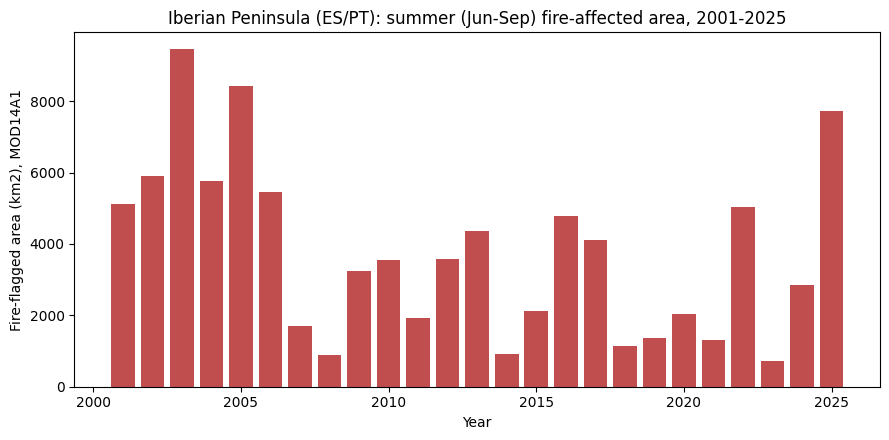

In [6]:
years = list(range(2001, 2026))
records = []
for y in years:
    area_m2 = summer_fire_pixel_count(y, aoi).getInfo()
    records.append({"year": y, "burned_area_km2": (area_m2 or 0) / 1e6})

df_trend = pd.DataFrame(records)

x = df_trend["year"].values
yv = df_trend["burned_area_km2"].values
if HAVE_MK:
    result = mk.original_test(yv)
    print(f"Mann-Kendall trend: {result.trend}, p = {result.p:.4f}, Sen's slope = {result.slope:.2f} km2/yr")
else:
    slope, intercept, r, p, se = stats.linregress(x, yv)
    print(f"Linear trend: slope = {slope:.2f} km2/yr, R2 = {r**2:.3f}, p = {p:.4f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(df_trend["year"], df_trend["burned_area_km2"], color="firebrick", alpha=0.8)
ax.set_title("Iberian Peninsula (ES/PT): summer (Jun-Sep) fire-affected area, 2001-2025")
ax.set_xlabel("Year"); ax.set_ylabel("Fire-flagged area (km2), MOD14A1")
plt.tight_layout()
plt.savefig("part2_trend_2001_2025.png", dpi=150)
plt.show()

# Known check: 2017 should stand out clearly (Pedrogao Grande / Galicia fires,
# among the most destructive in Iberian history). If it doesn't, that's this
# post's version of Part 1's "2021 sanity check" -- re-verify with Aqua before
# trusting the Terra series.


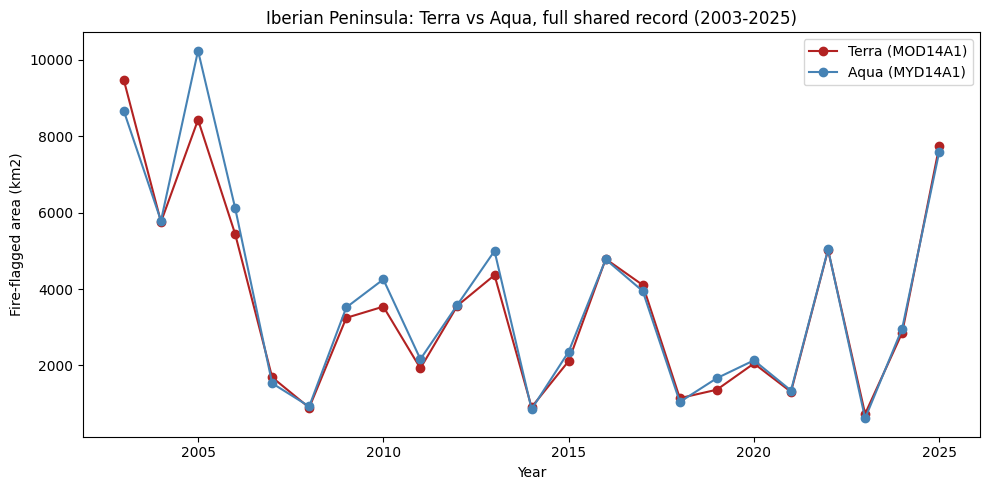

In [7]:
aqua_years = list(range(2003, 2026))
aqua_records = []
for y in aqua_years:
    area_m2 = summer_fire_pixel_count_myd(y, aoi).getInfo()
    aqua_records.append({"year": y, "aqua_burned_area_km2": (area_m2 or 0) / 1e6})

df_trend_aqua = pd.DataFrame(aqua_records)

fig, ax = plt.subplots(figsize=(10, 5))
df_terra_shared = df_trend[df_trend["year"].isin(aqua_years)]
ax.plot(df_terra_shared["year"], df_terra_shared["burned_area_km2"], marker="o", color="firebrick", label="Terra (MOD14A1)")
ax.plot(df_trend_aqua["year"], df_trend_aqua["aqua_burned_area_km2"], marker="o", color="steelblue", label="Aqua (MYD14A1)")
ax.set_title("Iberian Peninsula: Terra vs Aqua, full shared record (2003-2025)")
ax.set_xlabel("Year"); ax.set_ylabel("Fire-flagged area (km2)")
ax.legend()
plt.tight_layout()
plt.savefig("part2_terra_vs_aqua_full_series.png", dpi=150)
plt.show()


## 3. Recent detail — VIIRS 375 m (2023-2026) and current-season snapshot

In [8]:
def viirs_summer_hotspot_count(year, geom):
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    snpp = ee.ImageCollection("NASA/LANCE/SNPP_VIIRS/C2").filterDate(start, end)
    noaa20 = ee.ImageCollection("NASA/LANCE/NOAA20_VIIRS/C2").filterDate(start, end)
    combined = snpp.merge(noaa20)
    detections = combined.select("Bright_ti4").map(lambda img: img.gt(0)).sum().gt(0)
    stats_ = detections.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=geom, scale=375, maxPixels=1e10
    )
    return stats_.get("Bright_ti4")

recent_years = [2024, 2025, 2026]
recent_records = []
for y in recent_years:
    area_m2 = viirs_summer_hotspot_count(y, aoi).getInfo()
    recent_records.append({"year": y, "hotspot_area_km2": (area_m2 or 0) / 1e6})

df_recent = pd.DataFrame(recent_records)
df_recent

# Reminder from Part 1: if running this before Sep 30, 2026, the 2026 row is a
# partial season. Prorate by days elapsed (Jun 1 - today) before comparing to
# the complete 2024/2025 seasons.


,year,hotspot_area_km2
0,2024,5339.371757
1,2025,11598.798783
2,2026,4414.622748


In [9]:
today = datetime.datetime.utcnow().date()
window_start = (today - datetime.timedelta(days=30)).isoformat()
window_end = today.isoformat()

latest = ee.ImageCollection("NASA/LANCE/SNPP_VIIRS/C2") \
    .merge(ee.ImageCollection("NASA/LANCE/NOAA20_VIIRS/C2")) \
    .filterDate(window_start, window_end) \
    .select("Bright_ti4").max()

vis = {"min": 280, "max": 400, "palette": ["yellow", "orange", "red", "darkred"]}
Map2 = geemap.Map()
Map2.centerObject(aoi, 5)
Map2.addLayer(aoi, {"color": "gray"}, "AOI outline", opacity=0.3)
Map2.addLayer(latest.clip(aoi), vis, "VIIRS hotspots, last 30 days")
Map2


Map(center=[40.263015486494226, -4.1817839488319795], controls=(WidgetControl(options=['position', 'transparen…

## 4. Sub-regional split: Mediterranean south vs. Atlantic northwest

Using FAO GAUL level-1 boundaries. **Check the printed region-name list below before filtering** -- GAUL naming/diacritics for Spanish and Portuguese administrative units can be inconsistent (e.g. `Cataluna` vs `Catalonia`, accented vs unaccented forms).

In [10]:
gaul = ee.FeatureCollection("FAO/GAUL/2015/level1")

es_regions = gaul.filter(ee.Filter.eq("ADM0_NAME", "Spain"))
pt_regions = gaul.filter(ee.Filter.eq("ADM0_NAME", "Portugal"))

print("Spain ADM1 names:", sorted(es_regions.aggregate_array("ADM1_NAME").getInfo()))
print("Portugal ADM1 names:", sorted(pt_regions.aggregate_array("ADM1_NAME").getInfo()))


Spain ADM1 names: ['Andalucía', 'Aragón', 'Canarias', 'Cantabria', 'Castilla y León', 'Castilla-La Mancha', 'Cataluña/Catalunya', 'Ciudad Autónoma de Ceuta', 'Ciudad Autónoma de Melilla', 'Comunidad Foral de Navarra', 'Comunidad de Madrid', 'Comunitat Valenciana', 'Extremadura', 'Galicia', 'Illes Balears', 'La Rioja', 'País Vasco/Euskadi', 'Principado de Asturias', 'Región de Murcia']
Portugal ADM1 names: ['Aveiro', 'Beja', 'Braga', 'Braganca', 'Castelo Branco', 'Coimbra', 'Evora', 'Faro', 'Guarda', 'Leiria', 'Lisboa', 'Portalegre', 'Porto', 'Santarem', 'Setubal', 'Viana Do Castelo', 'Vila Real', 'Viseu']


In [15]:
# --- Corrected sub-region definitions (paste in place of the old cell) ---
med_south_names = ["Andalucía", "Región de Murcia", "Comunitat Valenciana", "Cataluña/Catalunya", "Illes Balears"]
atlantic_nw_names = ["Galicia"]  # Spain side
atlantic_nw_pt_names = [
    "Viana Do Castelo", "Braga", "Porto", "Aveiro", "Braganca", "Vila Real",
    "Viseu", "Guarda", "Coimbra", "Leiria"
]  # Portugal: Norte + Centro districts, north of Lisboa/Santarem -- includes Pedrogao Grande (Leiria)

med_south_fc = es_regions.filter(ee.Filter.inList("ADM1_NAME", med_south_names))
atlantic_nw_fc = (es_regions.filter(ee.Filter.inList("ADM1_NAME", atlantic_nw_names))
                   .merge(pt_regions.filter(ee.Filter.inList("ADM1_NAME", atlantic_nw_pt_names))))

med_south_geom = med_south_fc.geometry().dissolve()
atlantic_nw_geom = atlantic_nw_fc.geometry().dissolve()

subregions = {
    "Mediterranean south": med_south_geom,
    "Atlantic/Central-North": atlantic_nw_geom,  # renamed to reflect the broader, corrected coverage
}

Map3 = geemap.Map()
Map3.centerObject(aoi, 5)
Map3.addLayer(atlantic_nw_geom, {"color": "steelblue"}, "Atlantic/Central-North (Galicia/Norte/Centro)")
Map3.addLayer(med_south_geom, {"color": "firebrick"}, "Mediterranean south")
Map3


Map(center=[40.26301548649442, -4.181783948832057], controls=(WidgetControl(options=['position', 'transparent_…

## 5. Percentile-based extreme-heat metric (relative, not fixed at 35°C)

For each sub-region, first build a per-pixel 90th-percentile summer daily-max-temperature threshold from the full 2001-2025 baseline, then count how many days each year exceed *that region's own* threshold -- rather than a single fixed °C cutoff that would systematically favor the hotter region.

⚠️ The baseline-building step processes 25 years x ~122 summer days of daily imagery per sub-region -- this can take a few minutes.

In [16]:
def build_heat_baseline(geom, start_year=2001, end_year=2025, percentile=90):
    """Per-pixel Nth-percentile summer daily max temp over the baseline period."""
    baseline_col = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
                     .filter(ee.Filter.calendarRange(6, 9, "month"))
                     .filter(ee.Filter.calendarRange(start_year, end_year, "year"))
                     .select("temperature_2m_max"))
    threshold_img = baseline_col.reduce(ee.Reducer.percentile([percentile])).rename("threshold")
    return threshold_img

def extreme_heat_days_relative(year, geom, threshold_img):
    """Mean number of Jun-Sep days exceeding the region's own baseline percentile."""
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    col = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
             .filterDate(start, end)
             .select("temperature_2m_max"))
    hot_day_count = col.map(lambda img: img.gt(threshold_img)).sum()
    val = hot_day_count.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=geom, scale=10000, maxPixels=1e9
    )
    return val.get("temperature_2m_max")

def summer_precip_total(year, geom):
    """Total Jun-Sep precipitation (m), area-averaged -- same as Part 1."""
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    col = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
             .filterDate(start, end)
             .select("total_precipitation_sum"))
    total_img = col.sum()
    val = total_img.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=geom, scale=10000, maxPixels=1e9
    )
    return val.get("total_precipitation_sum")


In [17]:
# --- Build baselines once per sub-region (expensive-ish, done outside the year loop) ---
heat_baselines = {label: build_heat_baseline(geom) for label, geom in subregions.items()}

subregion_records = []
for label, geom in subregions.items():
    area_km2 = region_area_km2(geom)
    threshold_img = heat_baselines[label]
    for y in years:
        fire_m2 = summer_fire_pixel_count(y, geom).getInfo()
        heat_days = extreme_heat_days_relative(y, geom, threshold_img).getInfo()
        precip = summer_precip_total(y, geom).getInfo()
        subregion_records.append({
            "region": label,
            "year": y,
            "fire_area_km2": (fire_m2 or 0) / 1e6,
            "region_area_km2": area_km2,
            "extreme_heat_days_p90": heat_days,
            "summer_precip_m": precip
        })

df_iberia = pd.DataFrame(subregion_records)
df_iberia["fire_density_pct"] = df_iberia["fire_area_km2"] / df_iberia["region_area_km2"] * 100

baseline_precip = df_iberia.groupby("region")["summer_precip_m"].transform("mean")
df_iberia["precip_anomaly_pct"] = (df_iberia["summer_precip_m"] - baseline_precip) / baseline_precip * 100

df_iberia.head()


,region,year,fire_area_km2,region_area_km2,extreme_heat_days_p90,summer_precip_m,fire_density_pct,precip_anomaly_pct
0,Mediterranean south,2001,1149.808898,158872.864913,6.020332,0.114315,0.723729,-2.037289
1,Mediterranean south,2002,1921.298973,158872.864913,1.375263,0.135374,1.209331,16.009177
2,Mediterranean south,2003,2195.638145,158872.864913,16.088934,0.088542,1.382010,-24.123782
3,Mediterranean south,2004,1404.296006,158872.864913,6.599703,0.075171,0.883912,-35.582273
4,Mediterranean south,2005,433.997112,158872.864913,6.603121,0.094202,0.273173,-19.273290


Fire density vs relative (p90) extreme-heat days, by sub-region:
  Mediterranean south: r = -0.19, p = 0.370, n = 25
  Atlantic/Central-North: r = 0.64, p = 0.001, n = 25

Fire density vs precipitation anomaly, by sub-region:
  Mediterranean south: r = -0.36, p = 0.073, n = 25
  Atlantic/Central-North: r = -0.50, p = 0.011, n = 25


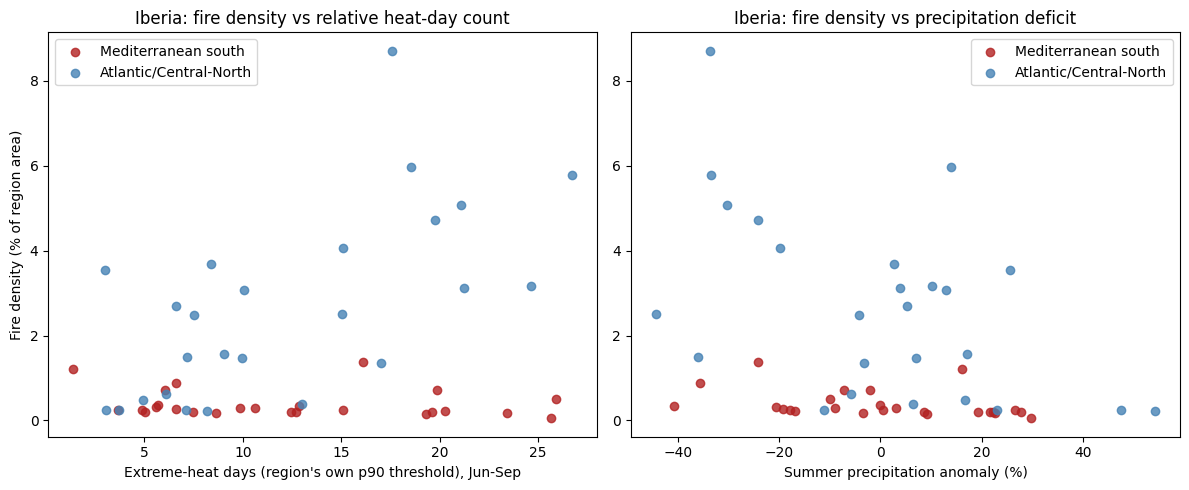

In [18]:
print("Fire density vs relative (p90) extreme-heat days, by sub-region:")
for label in subregions:
    sub = df_iberia[df_iberia["region"] == label]
    r, p = stats.pearsonr(sub["extreme_heat_days_p90"], sub["fire_density_pct"])
    print(f"  {label}: r = {r:.2f}, p = {p:.3f}, n = {len(sub)}")

print("\nFire density vs precipitation anomaly, by sub-region:")
for label in subregions:
    sub = df_iberia[df_iberia["region"] == label]
    r, p = stats.pearsonr(sub["precip_anomaly_pct"], sub["fire_density_pct"])
    print(f"  {label}: r = {r:.2f}, p = {p:.3f}, n = {len(sub)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sub_colors = {"Mediterranean south": "firebrick", "Atlantic/Central-North": "steelblue"}
for label in subregions:
    sub = df_iberia[df_iberia["region"] == label]
    axes[0].scatter(sub["extreme_heat_days_p90"], sub["fire_density_pct"], label=label, color=sub_colors[label], alpha=0.8)
    axes[1].scatter(sub["precip_anomaly_pct"], sub["fire_density_pct"], label=label, color=sub_colors[label], alpha=0.8)

axes[0].set_xlabel("Extreme-heat days (region's own p90 threshold), Jun-Sep")
axes[0].set_ylabel("Fire density (% of region area)")
axes[0].set_title("Iberia: fire density vs relative heat-day count")
axes[0].legend()

axes[1].set_xlabel("Summer precipitation anomaly (%)")
axes[1].set_title("Iberia: fire density vs precipitation deficit")
axes[1].legend()

plt.tight_layout()
plt.savefig("part2_extreme_days_relative_by_subregion.png", dpi=150)
plt.show()

# Interpretation guide:
# - If Atlantic NW shows a WEAKER climate correlation than Mediterranean south
#   even with the relative threshold, that supports the fuel-type/ignition-source
#   hypothesis from Part 1 (Turkey's anomaly) -- climate isn't the primary driver
#   in a eucalyptus-plantation fire regime the way it is in a drought-driven one.
# - If the relative threshold now picks up a real signal in the Atlantic NW that
#   a fixed 35C cutoff would have missed entirely, that's the headline
#   methodological finding for this post: absolute thresholds silently encode
#   an assumption about which climate the "extreme" is relative to.


## 6. Notes for the write-up (fill in after running)

- [ ] Trend headline number + Terra/Aqua agreement (does 2017 show up as the
  expected peak? If not on Terra alone, check Aqua before trusting it).
- [ ] Relative (p90) heat-day correlation: Mediterranean south vs Atlantic
  northwest -- does the fuel-type hypothesis hold, or does climate matter
  more than expected even in the eucalyptus belt?
- [ ] Precipitation deficit correlation, same split.
- [ ] Direct comparison to Part 1: does Mediterranean-south Iberia pattern
  more like Greece (heat-driven) or Türkiye's coast (drought-driven, weak
  signal either way)?
- [ ] Where 2026's season sits, prorated by days elapsed -- same caveat as
  Part 1, don't compare a partial season to complete ones without adjusting.
- [ ] One named anomalous year (2017 is the obvious candidate) as the
  sanity check that the pipeline captured a known, real event.

## 7. Next in the series

**Part 3 — Scandinavia / Baltic boreal fire.** A genuinely different regime:
peat, permafrost-adjacent hydrology, and a much sharper climate-change
signal in the literature. The relative-percentile heat metric and
area-normalized fire density from this notebook should carry over directly;
the open question is whether the same extreme-event framing (heat days,
precip deficit) is even the right lens for a boreal/peat regime, or whether
a different variable (e.g. drought code / fire weather index components)
would be more physically appropriate there.
